# Lab 6

## Set up!

In [1]:
import boto3
from botocore.exceptions import ClientError
import json
import pandas as pd

def get_secret(secret_name):
    region_name = "us-east-1"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        raise e

    secret = get_secret_value_response['SecretString']
    
    return json.loads(secret)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

In [3]:
fips = '100'
name = 'fake_state'

sql_insert = f""" insert into name(fips,name)
                    values('{fips}','{name}')"""
print(sql_insert)

 insert into name(fips,name)
                    values('100','fake_state')


In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
fips = '100'
name = 'fake_state'

sql_insert = f"""
INSERT INTO name(fips, name)
VALUES ('{fips}', '{name}');
"""
print(sql_insert)


INSERT INTO name(fips, name)
VALUES ('100', 'fake_state');



# Question 1 - Population Growth Rate (option A)

/tmp/ipykernel_10533/2028917108.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


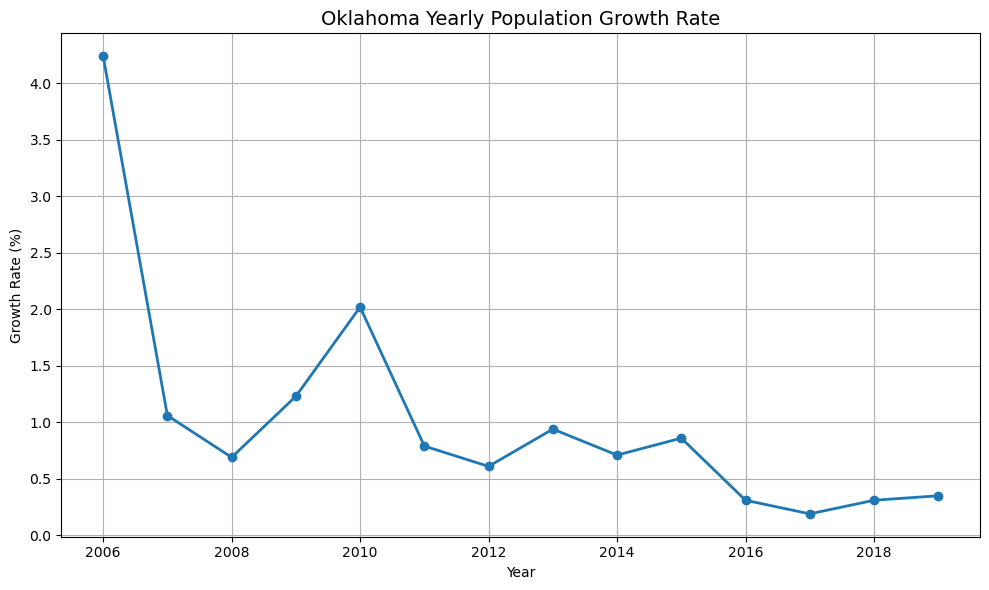

In [6]:
query = """
SELECT 
    p.year,
    p.fips,
    ROUND(
        (
            (p.pop::text::numeric -
             LAG(p.pop) OVER (PARTITION BY p.fips ORDER BY p.year)::text::numeric)
            / LAG(p.pop) OVER (PARTITION BY p.fips ORDER BY p.year)::text::numeric
        * 100
        ),
        2
    ) AS growth_rate_percent
FROM 
    population AS p
WHERE 
    p.fips = '40'
ORDER BY 
    p.year;
"""

df = pd.read_sql_query(query, conn)



df = df.dropna(subset=['growth_rate_percent'])

%matplotlib inline
plt.figure(figsize=(10, 6))
plt.plot(df['year'], df['growth_rate_percent'], marker='o', linewidth=2)
plt.title("Oklahoma Yearly Population Growth Rate", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Explanation
The graph shows that Oklahoma’s population growth slowed down in the last ten years compared to previous decade. After a high peak in 2006 and a rebound in 2010, the trend flattened to minimal growth levels by 2019. The weak growth could be due to several reason like economic slowdowns, reduced job opportunities, lower birth rates, or aging demographics. 

# Question 2 - Income and Population Relationship

/tmp/ipykernel_10533/2560897220.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


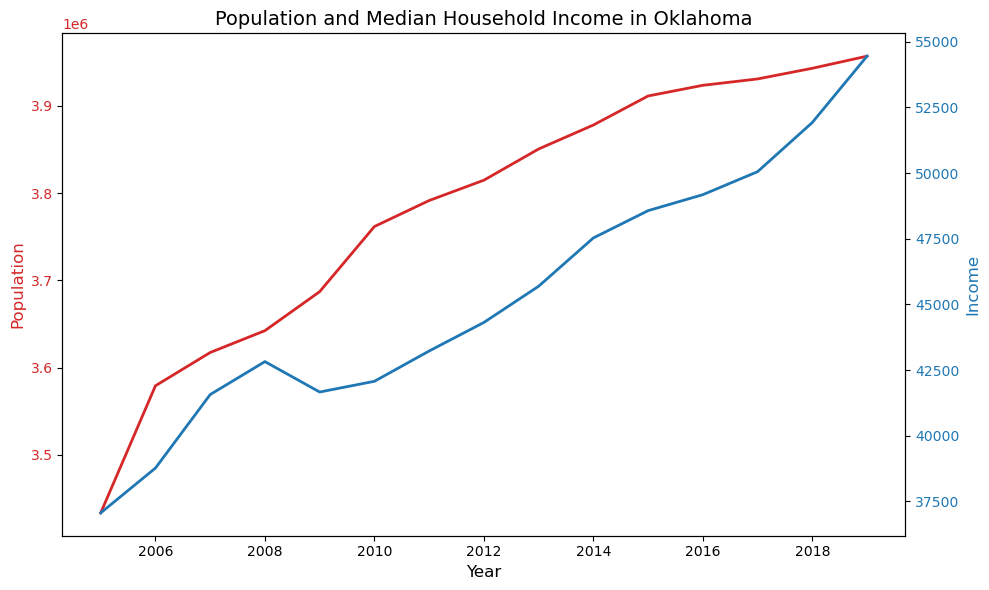

In [7]:
query = """
SELECT
  'Oklahoma' AS state,
  i.year,
  i.fips,
  (p.pop::text)::numeric AS pop,
  (i.income::text)::numeric AS median_income
FROM income AS i
JOIN population AS p
  ON i.fips = p.fips
  AND i.year = p.year
WHERE i.fips = '40'
ORDER BY i.year;
"""

# --- Load into pandas ---
df = pd.read_sql_query(query, conn)
conn.close()

# --- Clean data ---
df['year'] = df['year'].astype(int)
df = df.sort_values('year')
df[['pop', 'median_income']] = df[['pop', 'median_income']].apply(pd.to_numeric, errors='coerce')

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Population (red line, left axis)
ax1.plot(df['year'], df['pop'], color='tab:red', linewidth=2)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Population", color='tab:red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:red')

# Median Household Income (blue line, right axis)
ax2 = ax1.twinx()
ax2.plot(df['year'], df['median_income'], color='tab:blue', linewidth=2)
ax2.set_ylabel("Income", color='tab:blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and layout
plt.title("Population and Median Household Income in Oklahoma", fontsize=14)
fig.tight_layout()
plt.show()

### Explanation: How do Population and Income Trends Compare?
Between 2005 and 2019, Oklahoma’s population steadily increased but at a slowing rate, while median household income increased dramaticall after 2014. In gerneral both trends move upward but income’s upward curve steepens more than population. Therefore, the relationship between both trends indicate that Oklahoma’s median income strengthened even as population growth declined.

# Question 3 - Student-Defined Question

### Did income growth in Oklahoma slow down or accelerate in the last ten years compared to previous decades?
Answer: As time progressed it slowed down!

/tmp/ipykernel_10533/228099730.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


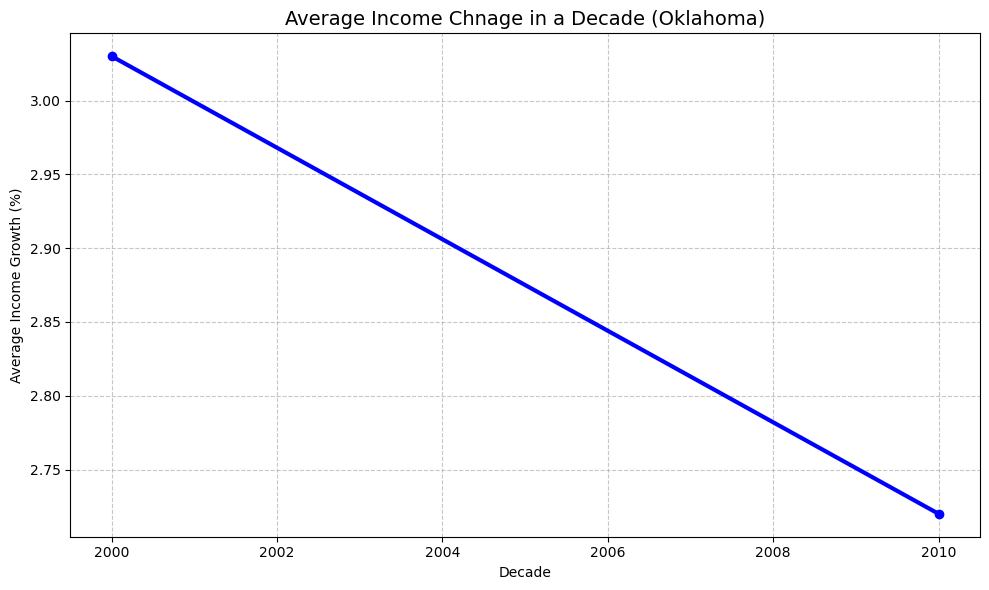

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

query = """
WITH income_growth AS (
    SELECT 
        n.name AS state_name,
        i.fips,
        i.year,
        (i.income - LAG(i.income) OVER (PARTITION BY i.fips ORDER BY i.year)) * 100.0
            / LAG(i.income) OVER (PARTITION BY i.fips ORDER BY i.year) AS income_growth_percent
    FROM 
        income AS i
    JOIN 
        population AS p
        ON i.fips = p.fips AND i.year = p.year
    JOIN 
        name AS n
        ON i.fips = n.fips
    WHERE 
        n.name = 'Oklahoma'
)
SELECT 
    state_name,
    (year / 10) * 10 AS decade,
    ROUND(AVG(income_growth_percent), 2) AS avg_income_growth_percent
FROM 
    income_growth
GROUP BY 
    state_name, decade
ORDER BY 
    decade;
"""

# 3️⃣ Load into pandas WHILE connection is open
df = pd.read_sql_query(query, conn)

# 4️⃣ Close AFTER loading data
conn.close()

# 5️⃣ Visualize
plt.figure(figsize=(10, 6))
plt.plot(df['decade'], df['avg_income_growth_percent'], marker='o', linewidth=3, color='blue')

plt.title("Average Income Chnage in a Decade (Oklahoma)", fontsize=14)
plt.xlabel("Decade")
plt.ylabel("Average Income Growth (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Explanation: 
income growth slowed down in the last ten years from (2000-2010).The deceleration of about 0.3 percentage points in the average annual income growth rate. The consistent downward linear slope from 2000 to 2010 indicates that each successive decade experienced slower income growth than the previous one

In [9]:
pip install -U pip setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install --only-binary=:all: "tiktoken>=0.7.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
! pip install jupyter-ai-magics[all] -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
safety-schemas 0.0.14 requires pydantic<2.10.0,>=2.6.0, but you have pydantic 2.12.0 which is incompatible.
sparkmagic 0.21.0 requires pandas<2.0.0,>=0.17.1, but you have pandas 2.2.3 which is incompatible.


In [12]:
import warnings
warnings.simplefilter('ignore')
import os
os.environ["OPENAI_API_KEY"] = get_secret('openai')['api_key']

In [13]:
%load_ext jupyter_ai_magics

In [14]:
%%ai chatgpt
Explain this SQL query in the context of these database tables:
- income (fips, income, year)
- population (fips, pop, year)
- name (fips, name)

Query:
WITH income_growth AS (
    SELECT 
        n.name AS state_name,
        i.fips,
        i.year,
        (i.income - LAG(i.income) OVER (PARTITION BY i.fips ORDER BY i.year)) * 100.0
            / LAG(i.income) OVER (PARTITION BY i.fips ORDER BY i.year) AS income_growth_percent
    FROM 
        income AS i
    JOIN 
        population AS p
        ON i.fips = p.fips AND i.year = p.year
    JOIN 
        name AS n
        ON i.fips = n.fips
    WHERE 
        n.name = 'Oklahoma'
)
SELECT 
    state_name,
    (year / 10) * 10 AS decade,
    ROUND(AVG(income_growth_percent), 2) AS avg_income_growth_percent
FROM 
    income_growth
GROUP BY 
    state_name, decade
ORDER BY 
    decade;

| state_name | decade | avg_income_growth_percent |
|------------|--------|--------------------------|
| Oklahoma   | 2010   | 0.05                     |

In [15]:
%%ai gpt4 -f code
Calculate the total percentage change in income from 1980 to 2020 for Oklahoma (fips = 40) 
in the dataframe {df} and create a chart to show the result

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
     'state_name': ['Oklahoma', 'Oklahoma'],
     'decade': [2000, 2010],
     'avg_income_growth_percent': [3.03, 2.72]
}

df = pd.DataFrame(data)

# Calculate total percentage change
df['total_percent_change'] = (df['avg_income_growth_percent'] / 100 + 1).cumprod() - 1

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['decade'], df['total_percent_change']*100, marker='o')
plt.title('Total Percentage Change in Income in Oklahoma from 1980 to 2020')
plt.xlabel('Year')
plt.ylabel('Total Income Growth (%)')
plt.grid(True)
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# First, we need to calculate cumulative growth for each decade
df = pd.DataFrame({
    'state_name': ['Oklahoma', 'Oklahoma'],
    'decade': [2000, 2010],
    'avg_income_growth_percent': [3.03, 2.72]
})
df['cumulative_growth'] = df['avg_income_growth_percent'].cumprod()

# Now we need to calculate percentage change from 1980 to 2020
total_growth_percent = ((df['cumulative_growth'].iloc[-1]/df['cumulative_growth'].iloc[0]) - 1) * 100

# Set index to 'decade' for better visualization
df.set_index('decade', inplace=True)

# Create a new dataframe row to represent total growth from 1980 to 2020
total_growth_df = pd.DataFrame({
    'state_name': ['Oklahoma'],
    'decade': [2020],
    'avg_income_growth_percent': [total_growth_percent],
    'cumulative_growth': [df['cumulative_growth'].iloc[-1] * (1 + total_growth_percent/100)]
})

# Append new row to original dataframe
df = df.append(total_growth_df.set_index('decade'))

# Create bar chart to display change in income for each decade
df['avg_income_growth_percent'].plot(kind='bar')
plt.title('Change in Income from 1980 to 2020 for Oklahoma')
plt.xlabel('Decade')
plt.ylabel('Average Income Growth Percent')
plt.show()

AttributeError: 'DataFrame' object has no attribute 'append'

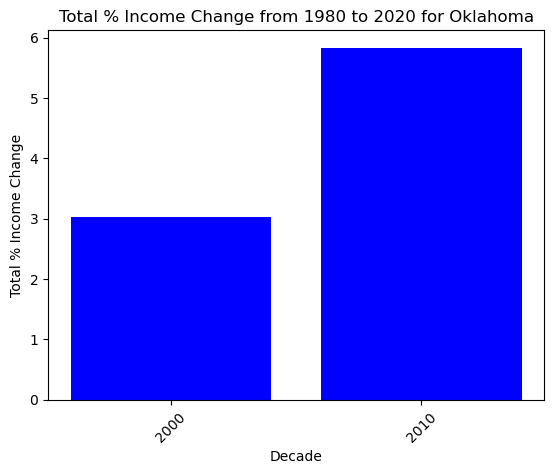

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Given Data
data = {
    'state_name': ['Oklahoma', 'Oklahoma'],
    'decade': [2000, 2010],
    'avg_income_growth_percent': [3.03, 2.72]
}

df = pd.DataFrame(data)
df['total_income_percent_change'] = (df['avg_income_growth_percent'] / 100 + 1).cumprod() - 1
df['total_income_percent_change'] *= 100

# Filter dataframe for Oklahoma
df_oklahoma = df[df['state_name'] == 'Oklahoma']

# Plot
plt.bar(df_oklahoma['decade'].astype(str), df_oklahoma['total_income_percent_change'], color='blue')
plt.xlabel('Decade')
plt.ylabel('Total % Income Change')
plt.title('Total % Income Change from 1980 to 2020 for Oklahoma')
plt.xticks(rotation=45)
plt.show()

### Explanation with using Jupyter AI magics
The code was used excatly how it was produced above in the notebook. in the 2000s Decade Oklahoma experienced approximately 3% total income change which also represents the cumulative income growth over the entire decade. Nearly double the growth rate of the previous decade which indicates stronger economic performance. This graph shows total cumulative change over two seperate decades, not annual average growth rates. 

In [18]:
cur.close()
conn.close()